# Attention U-Net for Retinal Artery-Vein Segmentation
## Multi-Label Formulation with Explicit Overlap Supervision

---

# What changed from the 4-class notebook

The network now predicts **three independent sigmoid channels** instead of a
4-way softmax:

| Channel | Positive where |
|---|---|
| `artery` | artery **or** crossing |
| `vein` | vein **or** crossing |
| `vessel` | any vessel pixel |

A crossing pixel is positive in **both** the artery and the vein channel.
That is what a crossing physically is: an artery passing over a vein. The
Overlap class is not removed -- it is recovered as the intersection, and it is
still reported in every table.

## Why the encoding matters

Under a 4-way softmax the three foreground classes compete for the same pixel:
the probabilities are forced to sum to one. At a crossing the network must
choose artery **or** vein **or** overlap, which requires it to learn that a
crossing has a distinctive appearance. It does not have one -- it looks like an
artery on top of a vein. Probability mass splits three ways and whichever of
artery/vein has stronger local evidence wins, so the overlap class is crushed.

The 4-class run showed exactly that:

```
Artery  0.6551 +/- 0.0207
Vein    0.7242 +/- 0.0094
Overlap 0.3748 +/- 0.0544   <- squeezed out by its own neighbours
```

Overlap also accounted for **79% of the total fold variance**, so it was both
the worst-scoring class and the reason every ablation was hard to resolve.

With independent sigmoids a crossing pixel accumulates artery evidence and vein
evidence separately. Both channels fire. The network never has to learn a third
appearance.

## Explicit overlap supervision

Deriving overlap from the intersection alone leaves nothing optimising it
directly. Because the intersection is differentiable, it can be supervised:

```
p_overlap = p_artery * p_vein
loss     += OVERLAP_WEIGHT * FocalTversky(p_overlap, gt_overlap)
```

The only way to reduce this term is to make **both** channels confident at
crossings, which is the physically correct behaviour. Overlap is optimised
directly without being modelled as a separate tissue type.

## clDice now runs on a connected tree

Previously clDice skeletonised three disjoint label maps, so an artery tree was
fragmented wherever a vein crossed it. It now runs on the `vessel` channel: one
complete, connected structure, which is what clDice was designed for. Expect it
to bite harder at the same weight -- which is why the weight is held at 0.10
for this run rather than raised.

## Other changes

| | Before | Now |
|---|---|---|
| `ALPHA` / `BETA` | 0.30 / 0.70 | **0.50 / 0.50** |
| Input channels | green+CLAHE replicated 3x | green+CLAHE, red+CLAHE, green-red |
| Encoder | ResNet34 | ResNet34 **+ full-resolution side branch** |
| Early stopping | 15 | 25 |
| Decision rule | `argmax` | per-channel threshold, tuned on validation |

**On ALPHA/BETA.** The 4-class run over-painted every vessel: measured
predicted/true vessel area was **1.212**, with false positives outweighing false
negatives 2.2 : 1. That is precisely what `BETA > ALPHA` instructs the model to
do -- it penalises a missed pixel 2.3x harder than an invented one. Dice weights
them equally, so the loss was optimising something the metric does not reward.
Symmetric alpha/beta is what Dice actually optimises.

**On the input.** Green maximises vessel-versus-background contrast, which is
why it is standard for binary vessel segmentation. But artery-versus-vein is a
*colour* discrimination: oxygenated haemoglobin absorbs less red, so arteries
stay bright and veins darken in the red channel, while green flattens both
equally. Replicating green three times discarded that signal and also fed the
ImageNet-pretrained stem -- whose first-layer filters are strongly
colour-opponent -- a flat grey input.

**On the encoder.** The scratch AttentionUNet had a skip connection at full
resolution. The ResNet34 stem downsamples by 2 immediately and pools again, so
`layer1` runs at quarter resolution and a 2-pixel vessel is sub-pixel before any
skip connection sees it. A shallow full-resolution side branch restores that
path, and with it the attention gate at full resolution, for about 0.1M extra
parameters.

## Not in this run

The channel-consistency constraint (`p_artery + p_vein - p_artery * p_vein`
should equal `p_vessel`) is deliberately held back so that the head change and
the constraint can be attributed separately. It is the next ablation.

---

In [1]:
import os
import cv2
import random
import shutil
from pathlib import Path

import numpy as np

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import albumentations as A

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


import warnings

# Silence the noisy albumentations and sklearn chatter, but keep
# DeprecationWarning visible so API drift surfaces instead of hiding.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("All libraries imported successfully.")

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


In [2]:
import json
from torch.utils.data import WeightedRandomSampler

In [3]:
# =============================================================================
# Configuration
# =============================================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# Dataset Paths
# =============================================================================

DATASET_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

IMAGE_FOLDER = os.path.join(DATASET_PATH, "images")
GT_FOLDER    = os.path.join(DATASET_PATH, "av")
ROI_FOLDER   = os.path.join(DATASET_PATH, "masks")

OUTPUT_DIR    = "./Processed_Dataset"
PROCESSED_DIR = os.path.join(OUTPUT_DIR, "processed")   # all frames, one flat tree
FOLD_DIR      = "./Fold_Dataset"                        # rebuilt per fold

# =============================================================================
# Cross-Validation Protocol
# =============================================================================
#
# The old single 34/8/8 split gave one estimate from 8 validation frames, with
# an empirical noise floor near +/- 0.02 Dice. Every effect measured so far was
# smaller than that, so the split could not support model selection.
#
# TEST_SIZE frames are held out once and never touched until the end. The
# remaining frames are split into N_FOLDS folds. Splitting happens at FRAME
# level, before patch extraction: patches use stride 128 on a 256 window, so a
# patch-level split would put overlapping pixels in both train and validation.

TEST_SIZE = 8
N_FOLDS   = 5

# Only trust a change when it clears this multiple of the across-fold std.
SIGNIFICANCE_SIGMA = 2.0

# =============================================================================
# Image / Patch Configuration
# =============================================================================

IMAGE_SIZE = 768

PATCH_SIZE = 256
PATCH_STRIDE = 128
BATCH_SIZE = 8

# Tiled inference stride. Validation and test frames are scored by sliding a
# PATCH_SIZE window and averaging logits, so the network sees the same spatial
# scale it was trained on. Previously it trained on 256 patches and was scored
# on whole 768 frames.
TILE_STRIDE = 128

# Tiling means the network only ever sees PATCH_SIZE inputs, so the frame size
# itself has no divisibility requirement -- but the patch does. ResNet34
# downsamples 5 times.
assert PATCH_SIZE % 32 == 0, "PATCH_SIZE must be divisible by 32"

# Vessel-aware Patch Extraction
ENABLE_VESSEL_PATCHING = True

MIN_VESSEL_FRACTION = 0.01
MIN_ROI_FRACTION = 0.50

BACKGROUND_KEEP_RATIO = 0.05

# Sampler weighting (applied on top of the filter)
OVERLAP_BOOST = 3.0
WEIGHT_FLOOR = 0.002

# =============================================================================
# Architecture
# =============================================================================

# ---------------------------------------------------------------------------
# Encoder
# ---------------------------------------------------------------------------
#
#   "scratch"  : the original AttentionUNet, trained from random init
#   "resnet34" : ImageNet-pretrained ResNet34 encoder, same attention decoder
#
# With roughly 34 training frames, initialising 32.8M parameters from random is
# the dominant source of overfitting (train Dice 0.75 against val 0.62). A
# pretrained encoder is normally the single largest gain available on datasets
# this small. Kept as a switch so it stays a one-line ablation against the
# scratch model rather than replacing it.

ENCODER = "resnet34"

assert ENCODER in {"scratch", "resnet34"}

# Fine-tune the pretrained encoder at a fraction of the decoder learning rate.
# The decoder is random and needs to move; the encoder already has useful
# filters and full-rate updates destroy them early in training.
ENCODER_LR_SCALE = 0.1

# ResNet BatchNorm carries ImageNet running statistics. At batch size 8 on ~600
# distinct patches, letting those statistics drift is pure variance. Freezing
# keeps the encoder in eval mode throughout.
FREEZE_ENCODER_BN = True

# Channel width of the first encoder stage; every stage scales from it.
# 64 reproduces the previous network (~32.8M params). 32 gives ~8.2M, which is
# a far saner ratio against roughly 600 genuinely distinct patches. Left at 64
# so this run is comparable; sweep it as a one-line ablation.
BASE_WIDTH = 64

KERNEL_SIZE = 5
KERNEL_DEPTH = 2

assert KERNEL_SIZE % 2 == 1, (
    f"KERNEL_SIZE must be odd for symmetric padding, got {KERNEL_SIZE}."
)
assert 0 <= KERNEL_DEPTH <= 4, "KERNEL_DEPTH must be in [0, 4]"

NUM_CLASSES = 4

# =============================================================================
# Training Configuration
# =============================================================================

EPOCHS = 100

LR = 1e-4

# 1e-4 with AdamW's decoupled decay is close to no regularisation at all, and
# the previous run overfit hard (train Dice 0.75 against val 0.62).
WEIGHT_DECAY = 1e-2

NUM_WORKERS = 0

PIN_MEMORY = True

EARLY_STOPPING_PATIENCE = 25

# Exponential moving average of the weights. Cheap, and it damps the
# checkpoint-selection noise that a small validation set creates.
EMA_DECAY = 0.999

# =============================================================================
# Curriculum Learning
# =============================================================================
#
# clDice now starts at epoch 0 and ramps slowly.
#
# In every previous run the best validation epoch arrived BEFORE
# CLDICE_START_EPOCH, so the saved weights never contained the topology term
# and no claim about clDice was ever actually tested. Starting at 0 removes the
# failure mode entirely: the term is present in whatever checkpoint gets
# selected. The weight is lowered to 0.10, which is the usual working range.

CLDICE_START_EPOCH = 0
CLDICE_RAMP_EPOCHS = 15

FOCAL_TVERSKY_WEIGHT = 0.90
CLDICE_WEIGHT = 0.10

CLDICE_ITERATIONS = 6

# =============================================================================
# Focal Tversky Parameters
# =============================================================================
#
# BETA > ALPHA penalises false negatives 2.3x harder than false positives.
# The previous run behaved exactly as instructed: Artery P=0.56 / R=0.81, i.e.
# systematic over-painting. If the reported metric is Dice, ALPHA = BETA = 0.5
# is what Dice actually optimises. Left asymmetric here so this run stays
# comparable; sweep it once the fold harness is trusted.

ALPHA = 0.50
BETA = 0.50
GAMMA = 4 / 3

CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def fold_checkpoint(fold):
    return os.path.join(
        CHECKPOINT_DIR,
        f"attn_unet_{ENCODER}_w{BASE_WIDTH}"
        f"_k{KERNEL_SIZE}d{KERNEL_DEPTH}_fold{fold}.pth"
    )


print("=" * 62)
print(f"Device            : {DEVICE}")
print(f"Image / Patch     : {IMAGE_SIZE} / {PATCH_SIZE} (stride {PATCH_STRIDE})")
print(f"Tiled inference   : {PATCH_SIZE} window, stride {TILE_STRIDE}")
print(f"Protocol          : {N_FOLDS}-fold CV, {TEST_SIZE} frames held out")
print(f"Encoder           : {ENCODER}")
print(f"Base width        : {BASE_WIDTH}   (scratch encoder only)")
print(f"Kernel schedule   : {KERNEL_SIZE}x{KERNEL_SIZE} for first {KERNEL_DEPTH} stage(s)")
print(f"clDice            : epoch {CLDICE_START_EPOCH}, ramp {CLDICE_RAMP_EPOCHS}, "
      f"weight {CLDICE_WEIGHT}")
print(f"Weight decay      : {WEIGHT_DECAY}")
print(f"EMA decay         : {EMA_DECAY}")
print(f"Early stopping    : {EARLY_STOPPING_PATIENCE}")
print("=" * 62)

Device            : cuda
Image / Patch     : 768 / 256 (stride 128)
Tiled inference   : 256 window, stride 128
Protocol          : 5-fold CV, 8 frames held out
Encoder           : resnet34
Base width        : 64   (scratch encoder only)
Kernel schedule   : 5x5 for first 2 stage(s)
clDice            : epoch 0, ramp 15, weight 0.1
Weight decay      : 0.01
EMA decay         : 0.999
Early stopping    : 25


In [4]:
# =============================================================================
# Multi-Label Output Configuration
# =============================================================================
#
# Three independent sigmoid channels. Overlap is the intersection of artery and
# vein, supervised explicitly through the differentiable product.

CHANNELS = ["artery", "vein", "vessel"]
NUM_CHANNELS = len(CHANNELS)

# Reported classes: the three channels plus the derived intersection.
REPORT_NAMES = ["artery", "vein", "vessel", "overlap"]

# Weight on FocalTversky(p_artery * p_vein, gt_overlap).
# The only way to reduce this is to make BOTH channels confident at crossings.
OVERLAP_WEIGHT = 0.20

# Channel-consistency term is held back for the next ablation so that the head
# change and the constraint can be attributed separately.
CONSISTENCY_WEIGHT = 0.0

# Decision thresholds. Swept on validation folds only, never on test.
THRESHOLD_GRID = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
DEFAULT_THRESHOLD = 0.50

# Primary model-selection metric: mean Dice over artery, vein and overlap.
# Vessel is reported but excluded from selection -- it is the easiest channel
# and would otherwise dominate.
SELECTION_CLASSES = ["artery", "vein", "overlap"]

print(f"Channels          : {CHANNELS}  (+ overlap derived)")
print(f"Overlap weight    : {OVERLAP_WEIGHT}")
print(f"Alpha / Beta      : {ALPHA} / {BETA}")
print(f"Selection metric  : mean Dice over {SELECTION_CLASSES}")

Channels          : ['artery', 'vein', 'vessel']  (+ overlap derived)
Overlap weight    : 0.2
Alpha / Beta      : 0.5 / 0.5
Selection metric  : mean Dice over ['artery', 'vein', 'overlap']


In [5]:
# =============================================================================
# Collect Dataset Files
# =============================================================================

from glob import glob

image_paths = sorted(glob(os.path.join(IMAGE_FOLDER, "*")))
gt_paths    = sorted(glob(os.path.join(GT_FOLDER, "*")))
roi_paths   = sorted(glob(os.path.join(ROI_FOLDER, "*")))

assert len(image_paths) == len(gt_paths) == len(roi_paths), \
    "Mismatch between images, AV masks and ROI masks."

assert len(image_paths) > 0, "No images found -- check DATASET_PATH."

print("=" * 62)
print(f"Total Images : {len(image_paths)}")
print("=" * 62)

Total Images : 50


In [6]:
# =============================================================================
# Preprocessing Helper Functions
# =============================================================================

def apply_roi(image: np.ndarray, roi: np.ndarray) -> np.ndarray:
    """
    Retain only the retinal region using the ROI mask.
    """
    roi = (roi > 0).astype(np.uint8)
    return cv2.bitwise_and(image, image, mask=roi)


def extract_green(image: np.ndarray) -> np.ndarray:
    """
    Extract the green channel from an RGB fundus image.
    """
    return image[:, :, 1]


def apply_clahe(image: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    Apply CLAHE for local contrast enhancement.
    """
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    return clahe.apply(image)


def pad_to_square(image: np.ndarray,
                  pad_value: int = 0) -> np.ndarray:
    """
    Pad an image to make it square.
    """

    h, w = image.shape[:2]
    size = max(h, w)

    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if image.ndim == 2:
        value = pad_value
    else:
        value = (pad_value,) * image.shape[2]

    return cv2.copyMakeBorder(
        image,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=value
    )


def resize_image(image: np.ndarray,
                 interpolation: int) -> np.ndarray:
    """
    Resize image to the configured IMAGE_SIZE.
    """

    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=interpolation
    )

In [7]:
 
# RGB Mask to Class Mask
 

def rgb_to_class(mask):

    label = np.zeros(mask.shape[:2], dtype=np.uint8)

    # Background
    label[np.all(mask == [0, 0, 0], axis=-1)] = 0

    # Artery (Red)
    label[np.all(mask == [255, 0, 0], axis=-1)] = 1

    # Overlap (Green)
    label[np.all(mask == [0, 255, 0], axis=-1)] = 2

    # Vein (Blue)
    label[np.all(mask == [0, 0, 255], axis=-1)] = 3

    return label

In [8]:
# =============================================================================
# Preprocess One Sample -- three distinct input channels
# =============================================================================
#
# Previously: green+CLAHE replicated three times, so two of the three input
# channels carried zero information and the ImageNet-pretrained colour-opponent
# stem filters saw a flat grey image.
#
#   channel 0  green + CLAHE   strongest vessel / background contrast
#   channel 1  red   + CLAHE   arteries stay bright, veins darken --
#                              this is where the A/V signal lives
#   channel 2  green - red     explicit ratio, the discriminator made direct
#
# Set USE_RGB_INPUT = False to recover the old green-replicated behaviour for
# a clean one-line ablation.

USE_RGB_INPUT = True


def preprocess_sample(image_path, roi_path, gt_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    roi = cv2.imread(roi_path, 0)

    gt = cv2.imread(gt_path)
    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

    image = apply_roi(image, roi)

    if USE_RGB_INPUT:

        green = apply_clahe(image[:, :, 1])
        red   = apply_clahe(image[:, :, 0])

        # Centred difference, rescaled to the same 0-255 range as the others
        diff = (green.astype(np.int16) - red.astype(np.int16) + 255) // 2
        diff = diff.astype(np.uint8)

        image = cv2.merge([green, red, diff])

    else:

        image = extract_green(image)
        image = apply_clahe(image)
        image = cv2.merge([image, image, image])

    image = pad_to_square(image)

    image = resize_image(image, cv2.INTER_LINEAR)

    gt = rgb_to_class(gt)
    gt = pad_to_square(gt)
    gt = resize_image(gt, cv2.INTER_NEAREST)

    roi = pad_to_square(roi)
    roi = resize_image(roi, cv2.INTER_NEAREST)

    return image, gt, roi

In [9]:
# =============================================================================
# Preprocess Every Frame Once, Into One Flat Tree
# =============================================================================
#
# No train/val/test folders any more. Frames are preprocessed once and folds
# are formed later by selecting stems. This makes it impossible for the fold
# loop to accidentally inherit the old split.

for sub in ["images", "av", "masks"]:
    d = os.path.join(PROCESSED_DIR, sub)
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

for ip, gp, rp in tqdm(zip(image_paths, gt_paths, roi_paths),
                       total=len(image_paths), desc="preprocess"):

    image, gt, roi = preprocess_sample(ip, rp, gp)

    stem = Path(ip).stem

    cv2.imwrite(os.path.join(PROCESSED_DIR, "images", f"{stem}.png"),
                cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(PROCESSED_DIR, "av", f"{stem}.png"), gt)
    cv2.imwrite(os.path.join(PROCESSED_DIR, "masks", f"{stem}.png"), roi)

ALL_STEMS = sorted(Path(p).stem for p in
                   glob(os.path.join(PROCESSED_DIR, "images", "*")))

print(f"\nPreprocessed frames : {len(ALL_STEMS)}")
print(f"Label values found  : "
      f"{sorted(np.unique(cv2.imread(os.path.join(PROCESSED_DIR, 'av', ALL_STEMS[0] + '.png'), 0)).tolist())}")

preprocess: 100%|██████████| 50/50 [00:07<00:00,  6.33it/s]


Preprocessed frames : 50
Label values found  : [0, 1, 2, 3]


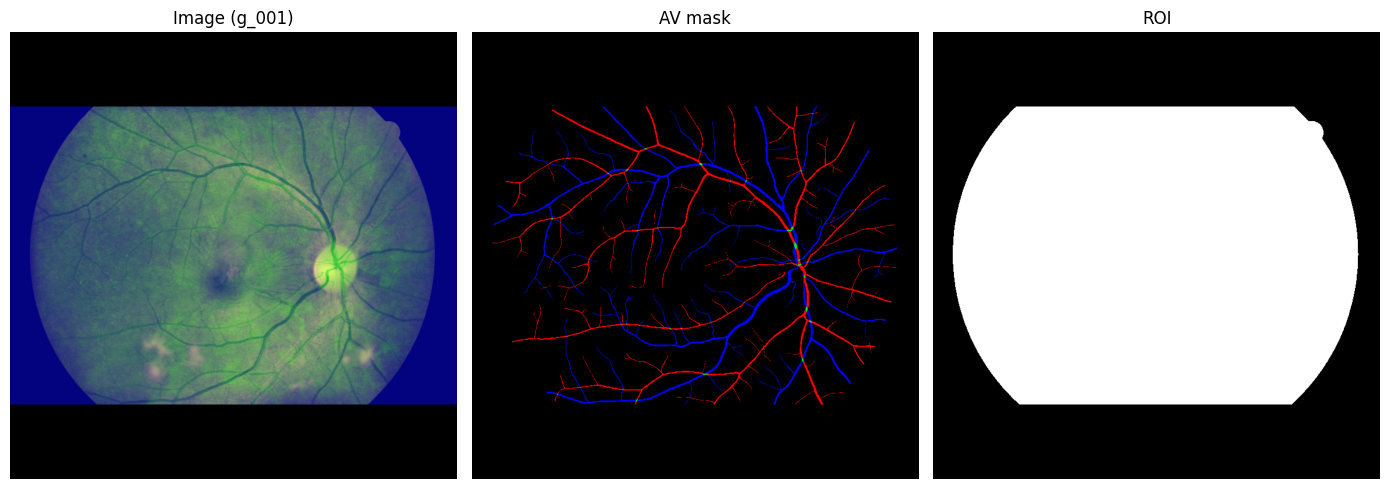

Image (768, 768, 3)  GT (768, 768)  ROI (768, 768)
GT classes present : [0, 1, 2, 3]


In [10]:
# =============================================================================
# Visual Verification
# =============================================================================

def class_to_rgb(mask):
    # Convert class mask back to RGB for visualization only.

    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    rgb[mask == 0] = [0, 0, 0]         # Background
    rgb[mask == 1] = [255, 0, 0]       # Artery
    rgb[mask == 2] = [0, 255, 0]       # Overlap
    rgb[mask == 3] = [0, 0, 255]       # Vein

    return rgb


_stem = ALL_STEMS[0]

_img = cv2.cvtColor(
    cv2.imread(os.path.join(PROCESSED_DIR, "images", f"{_stem}.png")),
    cv2.COLOR_BGR2RGB
)
_gt  = cv2.imread(os.path.join(PROCESSED_DIR, "av", f"{_stem}.png"), 0)
_roi = cv2.imread(os.path.join(PROCESSED_DIR, "masks", f"{_stem}.png"), 0)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, im, title in zip(
    axes,
    [_img, class_to_rgb(_gt), _roi],
    [f"Image ({_stem})", "AV mask", "ROI"]
):
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Image {_img.shape}  GT {_gt.shape}  ROI {_roi.shape}")
print(f"GT classes present : {sorted(np.unique(_gt).tolist())}")

In [11]:
# =============================================================================
# Fold Assignment
# =============================================================================
#
# Split at FRAME level. Patches overlap by 50% (stride 128, window 256), so a
# patch-level split leaks pixels across the boundary and inflates validation.

from sklearn.model_selection import KFold

_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(ALL_STEMS))

TEST_STEMS = sorted(ALL_STEMS[i] for i in _perm[:TEST_SIZE])
CV_STEMS   = sorted(ALL_STEMS[i] for i in _perm[TEST_SIZE:])

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

FOLDS = []

for tr_idx, va_idx in kf.split(CV_STEMS):

    tr = sorted(CV_STEMS[i] for i in tr_idx)
    va = sorted(CV_STEMS[i] for i in va_idx)

    FOLDS.append((tr, va))

# ---- leak assertions: these must never be relaxed ----

for f, (tr, va) in enumerate(FOLDS):

    assert not (set(tr) & set(va)), f"fold {f}: train/val frame overlap"
    assert not (set(tr) & set(TEST_STEMS)), f"fold {f}: train/test frame overlap"
    assert not (set(va) & set(TEST_STEMS)), f"fold {f}: val/test frame overlap"
    assert set(tr) | set(va) == set(CV_STEMS), f"fold {f}: frames lost"

assert not (set(CV_STEMS) & set(TEST_STEMS)), "cv/test frame overlap"

# Every CV frame is used for validation exactly once
_va_all = [x for _, va in FOLDS for x in va]
assert sorted(_va_all) == sorted(CV_STEMS), "fold coverage broken"
assert len(_va_all) == len(set(_va_all)), "frame validated twice"

# Persist so folds survive a kernel restart
with open("folds.json", "w") as fh:
    json.dump({"test": TEST_STEMS,
               "folds": [{"train": tr, "val": va} for tr, va in FOLDS]},
              fh, indent=2)

print("=" * 62)
print(f"Held-out test frames : {len(TEST_STEMS)}")
print(f"Cross-validated      : {len(CV_STEMS)} frames, {N_FOLDS} folds")
for f, (tr, va) in enumerate(FOLDS):
    print(f"  fold {f} : train {len(tr):>3d}  val {len(va):>3d}")
print("\nAll leak assertions passed. Splits written to folds.json")
print("=" * 62)

Held-out test frames : 8
Cross-validated      : 42 frames, 5 folds
  fold 0 : train  33  val   9
  fold 1 : train  33  val   9
  fold 2 : train  34  val   8
  fold 3 : train  34  val   8
  fold 4 : train  34  val   8

All leak assertions passed. Splits written to folds.json


In [12]:
def _rot(deg):
    return A.Rotate(limit=(deg, deg), border_mode=cv2.BORDER_CONSTANT,
                    interpolation=cv2.INTER_LINEAR,
                    mask_interpolation=cv2.INTER_NEAREST,
                    fill=0, fill_mask=0, p=1)

augmentations = {
    "hflip":        A.HorizontalFlip(p=1),
    "vflip":        A.VerticalFlip(p=1),
    "hvflip":       A.Compose([A.HorizontalFlip(p=1), A.VerticalFlip(p=1)]),
    "rot_p15":      _rot(15),
    "rot_m15":      _rot(-15),
    "rot_p25":      _rot(25),
    "rot_m25":      _rot(-25),
    "rot_p30":      _rot(30),
    "rot_m30":      _rot(-30),
    "hflip_rot20":  A.Compose([A.HorizontalFlip(p=1), _rot(20)]),
    "vflip_rot_m20":A.Compose([A.VerticalFlip(p=1), _rot(-20)]),

    "affine":       A.Affine(scale=(0.8, 1.15), translate_percent=(-0.05, 0.05),
                             shear=(-8, 8), interpolation=cv2.INTER_LINEAR,
                             mask_interpolation=cv2.INTER_NEAREST,
                             border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0, p=1),
    "elastic":      A.ElasticTransform(alpha=40, sigma=6,
                                       interpolation=cv2.INTER_LINEAR,
                                       mask_interpolation=cv2.INTER_NEAREST,
                                       border_mode=cv2.BORDER_CONSTANT,
                                       fill=0, fill_mask=0, p=1),

    "brightness":   A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
    "gamma":        A.RandomGamma(gamma_limit=(80, 120), p=1),
    "gaussian_blur":A.GaussianBlur(blur_limit=(3, 5), p=1),
    "gaussian_noise":A.GaussNoise(std_range=(0.02, 0.08), mean_range=(0.0, 0.0),
                                  per_channel=False, p=1),
}

# Register ROI as an additional mask target
augmentations = {
    k: A.Compose(
        v.transforms if isinstance(v, A.Compose) else [v],
        additional_targets={"roi": "mask"}
    )
    for k, v in augmentations.items()
}

In [13]:
# =============================================================================
# Per-Fold Dataset Construction
# =============================================================================
#
# Augmentation runs on the full 768x768 frame, BEFORE patching.
#
# Cutting patches first and then rotating them on a 256x256 canvas with
# BORDER_CONSTANT fill turns roughly a quarter of a 30-degree-rotated patch
# into synthetic black wedges that never occur at inference time, and 11 of the
# 18 variants are geometric. Augmenting the frame pushes those wedges to the
# frame corners, which already lie outside the retinal ROI. The ROI mask is
# warped with the frame, so wedge pixels get roi = 0 and the existing
# MIN_ROI_FRACTION criterion discards them with no extra logic.

INTENSITY_AUGS = {
    "brightness",
    "gamma",
    "gaussian_blur",
    "gaussian_noise"
}


def frame_variants(image, gt, roi):
    """
    Yield (name, image, gt, roi): the original frame plus every augmentation.
    Intensity augmentations leave the masks untouched.
    """

    yield "orig", image, gt, roi

    for aug_name, aug in augmentations.items():

        if aug_name in INTENSITY_AUGS:

            out = aug(image=image)

            yield aug_name, out["image"], gt, roi

        else:

            out = aug(image=image, mask=gt, roi=roi)

            yield aug_name, out["image"], out["mask"], out["roi"]


def write_patches(image, gt, roi, base, out_dir, rng, stats):
    """
    Cut the patch grid out of one frame, write patches passing the filter.
    """

    for y in range(0, IMAGE_SIZE - PATCH_SIZE + 1, PATCH_STRIDE):
        for x in range(0, IMAGE_SIZE - PATCH_SIZE + 1, PATCH_STRIDE):

            stats["examined"] += 1

            gt_patch  = gt[y:y + PATCH_SIZE, x:x + PATCH_SIZE]
            roi_patch = roi[y:y + PATCH_SIZE, x:x + PATCH_SIZE]

            if ENABLE_VESSEL_PATCHING:

                vessel_fraction = (gt_patch > 0).mean()
                roi_fraction    = (roi_patch > 0).mean()

                vessel_rich = (
                    vessel_fraction >= MIN_VESSEL_FRACTION
                    and roi_fraction >= MIN_ROI_FRACTION
                )

                if not vessel_rich:

                    if rng.random() >= BACKGROUND_KEEP_RATIO:
                        continue

                    stats["background"] += 1

            name = f"{base}_y{y}_x{x}.png"

            cv2.imwrite(
                os.path.join(out_dir, "images", name),
                cv2.cvtColor(image[y:y + PATCH_SIZE, x:x + PATCH_SIZE],
                             cv2.COLOR_RGB2BGR)
            )
            cv2.imwrite(os.path.join(out_dir, "av", name), gt_patch)
            cv2.imwrite(os.path.join(out_dir, "masks", name), roi_patch)

            stats["kept"] += 1


def build_fold_dataset(train_stems, verbose=True):
    """
    Wipe FOLD_DIR and rebuild the training patch set from the given frames.
    Validation frames are never patched -- they are scored whole, by tiling.
    """

    for sub in ["images", "av", "masks"]:
        d = os.path.join(FOLD_DIR, "train", sub)
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d, exist_ok=True)

    out_dir = os.path.join(FOLD_DIR, "train")

    rng = random.Random(SEED)
    stats = {"examined": 0, "kept": 0, "background": 0}

    it = tqdm(train_stems, desc="augment + patch") if verbose else train_stems

    for stem in it:

        image = cv2.cvtColor(
            cv2.imread(os.path.join(PROCESSED_DIR, "images", f"{stem}.png")),
            cv2.COLOR_BGR2RGB
        )
        gt  = cv2.imread(os.path.join(PROCESSED_DIR, "av", f"{stem}.png"), 0)
        roi = cv2.imread(os.path.join(PROCESSED_DIR, "masks", f"{stem}.png"), 0)

        for aug_name, ai, ag, ar in frame_variants(image, gt, roi):

            write_patches(ai, ag, ar, f"{stem}_{aug_name}",
                          out_dir, rng, stats)

    if verbose:
        n_var = 1 + len(augmentations)
        print(f"\nFrames   : {len(train_stems)} x {n_var} variants")
        print(f"Examined : {stats['examined']}")
        print(f"Kept     : {stats['kept']} "
              f"({stats['kept'] - stats['background']} vessel-rich, "
              f"{stats['background']} background)")

    return stats

In [14]:
# =============================================================================
# Datasets -- multi-label targets
# =============================================================================
#
# The class mask on disk stays 0/1/2/3. Conversion to channels happens here, so
# the patch tree written by build_fold_dataset is unchanged and the two
# formulations read the same files.

def class_mask_to_channels(m):
    """
    0 background, 1 artery, 2 crossing, 3 vein
      ->  (3, H, W) float: artery, vein, vessel

    A crossing is positive in BOTH artery and vein. That is the whole point.
    """

    artery = ((m == 1) | (m == 2)).astype(np.float32)
    vein   = ((m == 3) | (m == 2)).astype(np.float32)
    vessel = (m > 0).astype(np.float32)

    return np.stack([artery, vein, vessel], axis=0)


def overlap_from_class_mask(m):
    return (m == 2).astype(np.float32)


class PatchDataset(Dataset):
    """Training patches, read from the per-fold FOLD_DIR tree."""

    def __init__(self, image_dir, mask_dir, compute_weights=False):

        self.images = sorted(glob(os.path.join(image_dir, "*")))
        self.masks  = sorted(glob(os.path.join(mask_dir, "*")))

        assert len(self.images) == len(self.masks), \
            "Mismatch between images and masks."

        self.weights = None

        if compute_weights:

            w = []

            for m in tqdm(self.masks, desc="sample weights", leave=False):

                gt = cv2.imread(m, cv2.IMREAD_GRAYSCALE)

                vessel  = (gt > 0).mean()
                overlap = (gt == 2).mean()

                w.append(
                    max(vessel, WEIGHT_FLOOR) ** 0.5
                    + OVERLAP_BOOST * (overlap ** 0.5)
                )

            self.weights = np.array(w, dtype=np.float64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.cvtColor(cv2.imread(self.images[idx]), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)

        image = np.transpose(image.astype(np.float32) / 255.0, (2, 0, 1))

        channels = class_mask_to_channels(mask)
        overlap  = overlap_from_class_mask(mask)

        return (
            torch.from_numpy(image).float(),
            torch.from_numpy(channels).float(),
            torch.from_numpy(overlap).float(),
        )


class FrameDataset(Dataset):
    """Whole 768x768 frames. Validation and test only, never training."""

    def __init__(self, stems):
        self.stems = list(stems)

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):

        stem = self.stems[idx]

        image = cv2.cvtColor(
            cv2.imread(os.path.join(PROCESSED_DIR, "images", f"{stem}.png")),
            cv2.COLOR_BGR2RGB
        )
        mask = cv2.imread(os.path.join(PROCESSED_DIR, "av", f"{stem}.png"), 0)

        image = np.transpose(image.astype(np.float32) / 255.0, (2, 0, 1))

        return (
            torch.from_numpy(image).float(),
            torch.from_numpy(class_mask_to_channels(mask)).float(),
            torch.from_numpy(overlap_from_class_mask(mask)).float(),
        )

In [15]:
# Double Convolution Block

import math


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size=3):

        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError(
                f"kernel_size must be odd, got {kernel_size}. "
                "Even kernels cannot be symmetrically padded and will "
                "misalign the skip connections."
            )

        padding = kernel_size // 2

        groups = math.gcd(8, out_channels)

        self.kernel_size = kernel_size

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)


In [16]:
# Attention Gate

class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()


        groups = math.gcd(8, F_int)

        self.W_g = nn.Sequential(

            nn.Conv2d(
                F_g,
                F_int,
                kernel_size=1,
                bias=True
            ),

            nn.GroupNorm(
                groups,
                F_int
            )

        )

        self.W_x = nn.Sequential(

            nn.Conv2d(
                F_l,
                F_int,
                kernel_size=1,
                bias=True
            ),

            nn.GroupNorm(
                groups,
                F_int
            )

        )

        self.psi = nn.Sequential(

            nn.Conv2d(
                F_int,
                1,
                kernel_size=1,
                bias=True
            ),

            nn.Sigmoid()

        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

In [17]:
# Encoder Block

class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size=3):

        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels, kernel_size)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        skip = self.conv(x)

        pooled = self.pool(skip)

        return skip, pooled


In [18]:
# Decoder Block

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels,
                 kernel_size=3):

        super().__init__()

        # Upsampling stays 2x2 stride 2 regardless of the conv kernel --
        # this is a resampling op, not a feature extractor.
        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionBlock(
            F_g=out_channels,
            F_l=skip_channels,
            F_int=out_channels // 2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels,
            kernel_size
        )

    def forward(self, x, skip):

        x = self.up(x)

        skip = self.attention(x, skip)

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)


In [19]:
# Attention U-Net with Deep Supervision

class AttentionUNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=4, base_width=64,
                 kernel_size=3, kernel_depth=0):
        """
        base_width   : channels at the first encoder stage; every stage scales
                       from it. 64 reproduces the original network.
        kernel_size  : conv kernel for the shallow stages
        kernel_depth : how many encoder stages (from the top) use kernel_size.
                       Their mirrored decoder stages match. 0 = all 3x3.
        """

        super().__init__()

        # Per-stage kernel schedule: wide at full resolution, 3x3 deeper.
        k = [kernel_size if i < kernel_depth else 3 for i in range(4)]

        self.kernel_schedule = k

        w = base_width
        c1, c2, c3, c4 = w, w * 2, w * 4, w * 8
        cb = w * 16

        self.widths = [c1, c2, c3, c4, cb]

        # Encoder

        self.enc1 = EncoderBlock(in_channels, c1, k[0])
        self.enc2 = EncoderBlock(c1, c2, k[1])
        self.enc3 = EncoderBlock(c2, c3, k[2])
        self.enc4 = EncoderBlock(c3, c4, k[3])

        # Bottleneck -- always 3x3. It already has the largest receptive
        # field and by far the most parameters.

        self.bottleneck = DoubleConv(c4, cb, 3)

        # Decoder (mirrors the encoder schedule)

        self.dec4 = DecoderBlock(cb, c4, c4, k[3])
        self.dec3 = DecoderBlock(c4, c3, c3, k[2])
        self.dec2 = DecoderBlock(c3, c2, c2, k[1])
        self.dec1 = DecoderBlock(c2, c1, c1, k[0])

        # Main Output

        self.out = nn.Conv2d(c1, num_classes, kernel_size=1)

        # Deep Supervision Heads

        self.ds4 = nn.Conv2d(c4, num_classes, kernel_size=1)
        self.ds3 = nn.Conv2d(c3, num_classes, kernel_size=1)
        self.ds2 = nn.Conv2d(c2, num_classes, kernel_size=1)

        self.initialize_weights()

    def initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.GroupNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):

        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)

        b = self.bottleneck(p4)

        d4 = self.dec4(b, s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)

        out = self.out(d1)

        aux4 = self.ds4(d4)
        aux3 = self.ds3(d3)
        aux2 = self.ds2(d2)

        up = lambda t: F.interpolate(
            t, size=out.shape[2:], mode="bilinear", align_corners=False
        )

        return out, up(aux2), up(aux3), up(aux4)

In [20]:
# =============================================================================
# ResNet34 Encoder + Attention Decoder + Full-Resolution Side Branch
# =============================================================================
#
# ResNet34 downsamples immediately: conv1 has stride 2 and is followed by a
# stride-2 maxpool, so layer1 runs at quarter resolution. A 2-pixel vessel is
# sub-pixel before any skip connection sees it, and the shallowest skip
# available is at H/2 -- the final upsample has nothing to attend to.
#
# The scratch AttentionUNet had a full-resolution skip. The side branch below
# restores it: a shallow two-conv stack at native resolution, never
# downsampled, joined through an attention gate at the last decoder stage. The
# pretrained stem is left untouched and the cost is about 0.1M parameters.
#
# Set USE_FULLRES_BRANCH = False to recover the previous behaviour.

from torchvision.models import resnet34, ResNet34_Weights

USE_FULLRES_BRANCH = True


class FinalUp(nn.Module):
    """Last upsample, H/2 -> H, with no skip available."""

    def __init__(self, in_channels, out_channels, kernel_size=3):

        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels,
                                     kernel_size=2, stride=2)

        self.conv = DoubleConv(out_channels, out_channels, kernel_size)

    def forward(self, x):
        return self.conv(self.up(x))


class ResNetAttentionUNet(nn.Module):

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, num_channels=3, kernel_size=3, kernel_depth=0,
                 pretrained=True, freeze_bn=True, fullres_branch=True,
                 fullres_width=32):

        super().__init__()

        k = [kernel_size if i < kernel_depth else 3 for i in range(4)]

        self.kernel_schedule = k
        self.freeze_bn = freeze_bn
        self.fullres_branch = fullres_branch

        weights = ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        net = resnet34(weights=weights)

        self.stem   = nn.Sequential(net.conv1, net.bn1, net.relu)   #  64, H/2
        self.pool   = net.maxpool
        self.layer1 = net.layer1                                     #  64, H/4
        self.layer2 = net.layer2                                     # 128, H/8
        self.layer3 = net.layer3                                     # 256, H/16
        self.layer4 = net.layer4                                     # 512, H/32

        self.encoder_modules = [self.stem, self.layer1, self.layer2,
                                self.layer3, self.layer4]

        self.dec4 = DecoderBlock(512, 256, 256, k[3])
        self.dec3 = DecoderBlock(256, 128, 128, k[2])
        self.dec2 = DecoderBlock(128,  64,  64, k[1])
        self.dec1 = DecoderBlock(64,   64,  64, k[0])

        if fullres_branch:
            # Native resolution throughout -- this is the path thin vessels need
            self.stem_full = DoubleConv(3, fullres_width, k[0])
            self.final = DecoderBlock(64, fullres_width, fullres_width, k[0])
            head_ch = fullres_width
        else:
            self.final = FinalUp(64, 32, k[0])
            head_ch = 32

        self.out = nn.Conv2d(head_ch, num_channels, kernel_size=1)

        self.ds4 = nn.Conv2d(256, num_channels, kernel_size=1)
        self.ds3 = nn.Conv2d(128, num_channels, kernel_size=1)
        self.ds2 = nn.Conv2d(64,  num_channels, kernel_size=1)

        self.register_buffer("norm_mean",
                             torch.tensor(self.IMAGENET_MEAN).view(1, 3, 1, 1))
        self.register_buffer("norm_std",
                             torch.tensor(self.IMAGENET_STD).view(1, 3, 1, 1))

        self._init_decoder()

    def _init_decoder(self):

        blocks = [self.dec4, self.dec3, self.dec2, self.dec1, self.final,
                  self.out, self.ds4, self.ds3, self.ds2]

        if self.fullres_branch:
            blocks.append(self.stem_full)

        for block in blocks:
            for m in block.modules():

                if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                    nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                            nonlinearity="relu")
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

                elif isinstance(m, nn.GroupNorm):
                    nn.init.ones_(m.weight)
                    nn.init.zeros_(m.bias)

    def train(self, mode=True):

        super().train(mode)

        if mode and self.freeze_bn:
            for block in self.encoder_modules:
                for m in block.modules():
                    if isinstance(m, nn.BatchNorm2d):
                        m.eval()

        return self

    def encoder_parameters(self):
        for block in self.encoder_modules:
            yield from block.parameters()

    def decoder_parameters(self):
        enc = {id(p) for p in self.encoder_parameters()}
        for p in self.parameters():
            if id(p) not in enc:
                yield p

    def forward(self, x):

        xn = (x - self.norm_mean) / self.norm_std

        f1 = self.stem(xn)
        f2 = self.layer1(self.pool(f1))
        f3 = self.layer2(f2)
        f4 = self.layer3(f3)
        b  = self.layer4(f4)

        d4 = self.dec4(b,  f4)
        d3 = self.dec3(d4, f3)
        d2 = self.dec2(d3, f2)
        d1 = self.dec1(d2, f1)

        if self.fullres_branch:
            d0 = self.final(d1, self.stem_full(xn))
        else:
            d0 = self.final(d1)

        out = self.out(d0)

        up = lambda t: F.interpolate(t, size=out.shape[2:],
                                     mode="bilinear", align_corners=False)

        return out, up(self.ds2(d2)), up(self.ds3(d3)), up(self.ds4(d4))


def build_model():

    if ENCODER == "resnet34":

        return ResNetAttentionUNet(
            num_channels=NUM_CHANNELS,
            kernel_size=KERNEL_SIZE,
            kernel_depth=KERNEL_DEPTH,
            pretrained=True,
            freeze_bn=FREEZE_ENCODER_BN,
            fullres_branch=USE_FULLRES_BRANCH
        ).to(DEVICE)

    return AttentionUNet(
        in_channels=3,
        num_classes=NUM_CHANNELS,
        base_width=BASE_WIDTH,
        kernel_size=KERNEL_SIZE,
        kernel_depth=KERNEL_DEPTH
    ).to(DEVICE)


def build_optimizer(model):

    if ENCODER == "resnet34":

        return torch.optim.AdamW(
            [
                {"params": list(model.encoder_parameters()),
                 "lr": LR * ENCODER_LR_SCALE},
                {"params": list(model.decoder_parameters()), "lr": LR},
            ],
            weight_decay=WEIGHT_DECAY
        )

    return torch.optim.AdamW(model.parameters(), lr=LR,
                             weight_decay=WEIGHT_DECAY)

In [21]:
_m = build_model()
_n = sum(p.numel() for p in _m.parameters())

print(f"Encoder            : {ENCODER}")
print(f"Full-res branch    : {USE_FULLRES_BRANCH}")
print(f"Kernel schedule    : {_m.kernel_schedule}")
print(f"Parameters         : {_n:,}")

if ENCODER == "resnet34":
    _e = sum(p.numel() for p in _m.encoder_parameters())
    print(f"  encoder          : {_e:,} @ lr x{ENCODER_LR_SCALE}")
    print(f"  decoder          : {_n - _e:,} @ lr x1")

with torch.no_grad():
    _m.eval()
    _o = _m(torch.rand(1, 3, PATCH_SIZE, PATCH_SIZE, device=DEVICE))

assert len(_o) == 4, "model must return (main, aux2, aux3, aux4)"

for _i, _x in enumerate(_o):
    assert _x.shape[1] == NUM_CHANNELS, \
        f"head {_i} has {_x.shape[1]} channels, expected {NUM_CHANNELS}"
    assert _x.shape[-2:] == (PATCH_SIZE, PATCH_SIZE), \
        f"head {_i} shape {tuple(_x.shape)}"

print(f"Shape check        : OK, 4 heads x {NUM_CHANNELS} channels "
      f"at {PATCH_SIZE}x{PATCH_SIZE}")

del _m, _o

Encoder            : resnet34
Full-res branch    : True
Kernel schedule    : [5, 5, 3, 3]
Parameters         : 25,025,761
  encoder          : 21,284,672 @ lr x0.1
  decoder          : 3,741,089 @ lr x1
Shape check        : OK, 4 heads x 3 channels at 256x256


In [22]:
# =============================================================================
# Multi-Label Losses
# =============================================================================

class BinaryFocalTversky(nn.Module):
    """
    Focal Tversky on independent sigmoid channels.

    Statistics are accumulated over the whole BATCH rather than per sample.
    Per-sample reduction is fine for common classes but useless for crossings:
    most 256px patches contain none, so a per-sample Tversky index would be
    smooth/smooth = 1 and contribute no gradient at all. Batch accumulation
    keeps the rare class in the objective, which is the entire point of
    supervising overlap explicitly.
    """

    def __init__(self, alpha=ALPHA, beta=BETA, gamma=GAMMA, smooth=1e-6):

        super().__init__()

        self.alpha, self.beta = alpha, beta
        self.gamma, self.smooth = gamma, smooth

    def forward(self, probs, targets):
        # probs, targets : (B, C, H, W) in [0, 1]

        probs = probs.flatten(2).transpose(0, 1).flatten(1)      # (C, B*H*W)
        targets = targets.flatten(2).transpose(0, 1).flatten(1)

        TP = (probs * targets).sum(dim=1)
        FP = (probs * (1 - targets)).sum(dim=1)
        FN = ((1 - probs) * targets).sum(dim=1)

        tversky = (TP + self.smooth) / (
            TP + self.alpha * FP + self.beta * FN + self.smooth
        )

        return ((1.0 - tversky) ** self.gamma).mean()


class BinaryCLDice(nn.Module):
    """
    clDice on a single binary channel.

    Runs on the vessel channel, which is one complete connected tree. The
    4-class version skeletonised three disjoint label maps, so an artery tree
    was fragmented wherever a vein crossed it -- the topology term was being
    asked to preserve a structure the encoding had already broken.
    """

    def __init__(self, iterations=CLDICE_ITERATIONS, smooth=1e-6):

        super().__init__()

        self.iterations, self.smooth = iterations, smooth

    def forward(self, prob, target):
        # prob, target : (B, 1, H, W)

        skel_pred = soft_skeletonize(prob, self.iterations)
        skel_true = soft_skeletonize(target, self.iterations)

        t_prec = (
            (skel_pred * target).sum() + self.smooth
        ) / (skel_pred.sum() + self.smooth)

        t_sens = (
            (skel_true * prob).sum() + self.smooth
        ) / (skel_true.sum() + self.smooth)

        cl_dice = 2.0 * t_prec * t_sens / (t_prec + t_sens + self.smooth)

        return 1.0 - cl_dice


focal_tversky_loss = BinaryFocalTversky(ALPHA, BETA, GAMMA)
cldice_loss = BinaryCLDice(CLDICE_ITERATIONS)

A_IDX, V_IDX, BV_IDX = 0, 1, 2

In [23]:
 # Soft Skeletonization
 
def soft_erode(img):

    if img.dim() == 4:

        p1 = -F.max_pool2d(-img, (3,1), stride=1, padding=(1,0))

        p2 = -F.max_pool2d(-img, (1,3), stride=1, padding=(0,1))

        return torch.min(p1, p2)

    raise ValueError("Expected 4D tensor")


def soft_dilate(img):

    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):

    return soft_dilate(
        soft_erode(img)
    )


def soft_skeletonize(img, iterations=CLDICE_ITERATIONS):

    img1 = soft_open(img)

    skeleton = F.relu(img - img1)

    for _ in range(iterations):

        img = soft_erode(img)

        opened = soft_open(img)

        delta = F.relu(img-opened)

        skeleton = skeleton + F.relu(delta - skeleton*delta)

    return skeleton

In [24]:
# =============================================================================
# Hybrid Loss -- Option B (explicit overlap supervision)
# =============================================================================

def cldice_weight_at(epoch):
    """Linear ramp of the clDice weight from CLDICE_START_EPOCH."""

    if epoch < CLDICE_START_EPOCH:
        return 0.0

    progress = (epoch - CLDICE_START_EPOCH + 1) / max(1, CLDICE_RAMP_EPOCHS)

    return CLDICE_WEIGHT * min(1.0, progress)


def hybrid_loss(outputs, targets, overlap_gt, epoch=0):
    """
    outputs    : (main, aux2, aux3, aux4), each (B, 3, H, W) logits
    targets    : (B, 3, H, W)  artery, vein, vessel
    overlap_gt : (B, H, W)     crossings

    Terms
      1. Focal Tversky on the three channels          -- identity + extent
      2. clDice on the vessel channel                 -- topology of one tree
      3. Focal Tversky on p_artery * p_vein           -- crossings, explicit
      4. Deep supervision, Focal Tversky only
    """

    main, aux2, aux3, aux4 = outputs

    p = torch.sigmoid(main)

    ft_main = focal_tversky_loss(p, targets)

    # ---- topology, on the connected vessel tree ----

    w_cl = cldice_weight_at(epoch)

    if w_cl > 0.0:

        # Soft-skeleton iterations compound small errors; fp16 is not safe here
        with torch.amp.autocast("cuda", enabled=False):
            cl_main = cldice_loss(
                p[:, BV_IDX:BV_IDX + 1].float(),
                targets[:, BV_IDX:BV_IDX + 1].float()
            )

        main_loss = (1.0 - w_cl) * ft_main + w_cl * cl_main

    else:
        main_loss = ft_main

    # ---- crossings, supervised through the differentiable intersection ----
    #
    # p_overlap can only rise if BOTH channels are confident at the same pixel,
    # so this term pushes toward the physically correct behaviour rather than
    # toward a separate "crossing" appearance.

    if OVERLAP_WEIGHT > 0.0:

        p_overlap = (
            p[:, A_IDX:A_IDX + 1] * p[:, V_IDX:V_IDX + 1]
        )

        ov_loss = focal_tversky_loss(p_overlap, overlap_gt.unsqueeze(1))

        main_loss = main_loss + OVERLAP_WEIGHT * ov_loss

    # ---- channel consistency (held back for the next ablation) ----

    if CONSISTENCY_WEIGHT > 0.0:

        p_union = (
            p[:, A_IDX] + p[:, V_IDX] - p[:, A_IDX] * p[:, V_IDX]
        )

        main_loss = main_loss + CONSISTENCY_WEIGHT * (
            (p_union - p[:, BV_IDX]) ** 2
        ).mean()

    # ---- deep supervision: Focal Tversky only ----
    #
    # Topology loss on 2x/4x/8x downsampled logits is meaningless, and crossings
    # do not survive the downsampling either.

    aux_loss = (
        0.40 * focal_tversky_loss(torch.sigmoid(aux2), targets)
        + 0.25 * focal_tversky_loss(torch.sigmoid(aux3), targets)
        + 0.15 * focal_tversky_loss(torch.sigmoid(aux4), targets)
    )

    return main_loss + aux_loss


print("clDice ramp:")
for _e in range(0, CLDICE_START_EPOCH + CLDICE_RAMP_EPOCHS + 2, 3):
    print(f"  epoch {_e:>3d} : {cldice_weight_at(_e):.3f}")
print(f"\nOverlap weight     : {OVERLAP_WEIGHT}")
print(f"Consistency weight : {CONSISTENCY_WEIGHT}  (0 = held for next run)")

clDice ramp:
  epoch   0 : 0.007
  epoch   3 : 0.027
  epoch   6 : 0.047
  epoch   9 : 0.067
  epoch  12 : 0.087
  epoch  15 : 0.100

Overlap weight     : 0.2
Consistency weight : 0.0  (0 = held for next run)


In [25]:
# =============================================================================
# Multi-Label Metrics
# =============================================================================
#
# Every metric is computed at an explicit threshold. Overlap is derived as the
# intersection of the thresholded artery and vein maps -- the same rule used at
# inference, so the reported number is the one a user would get.
#
# A class absent from both prediction and target scores nan, not 1.0.

def binarise(probs, thresholds):
    """probs (B, 3, H, W) -> bool, per-channel thresholds."""

    t = torch.as_tensor(thresholds, device=probs.device).view(1, -1, 1, 1)

    return probs > t


def derived_masks(pred_bin, target, overlap_gt):
    """
    Returns dicts of (pred, true) boolean maps for all four reported classes.
    """

    pa, pv, pbv = pred_bin[:, A_IDX], pred_bin[:, V_IDX], pred_bin[:, BV_IDX]

    ta = target[:, A_IDX] > 0.5
    tv = target[:, V_IDX] > 0.5
    tbv = target[:, BV_IDX] > 0.5
    tov = overlap_gt > 0.5

    return {
        "artery":  (pa,       ta),
        "vein":    (pv,       tv),
        "vessel":  (pbv,      tbv),
        "overlap": (pa & pv,  tov),
    }


@torch.no_grad()
def multilabel_metrics(probs, target, overlap_gt, thresholds, smooth=1e-6):

    pred_bin = binarise(probs, thresholds)

    masks = derived_masks(pred_bin, target, overlap_gt)

    out = {}

    for name, (p, t) in masks.items():

        p = p.float()
        t = t.float()

        tp = (p * t).sum()
        fp = (p * (1 - t)).sum()
        fn = ((1 - p) * t).sum()

        if tp + fp + fn == 0:
            out[name] = {k: float("nan")
                         for k in ["dice", "iou", "precision", "recall", "f1"]}
            continue

        dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
        iou  = (tp + smooth) / (tp + fp + fn + smooth)
        prec = (tp + smooth) / (tp + fp + smooth)
        rec  = (tp + smooth) / (tp + fn + smooth)

        out[name] = {
            "dice": float(dice), "iou": float(iou),
            "precision": float(prec), "recall": float(rec),
            "f1": float(2 * prec * rec / (prec + rec + 1e-12)),
        }

    # Pixel accuracy over the reconstructed 4-class map
    pred_cls = torch.zeros_like(overlap_gt, dtype=torch.long)
    pa, pv = pred_bin[:, A_IDX], pred_bin[:, V_IDX]
    pred_cls[pa & ~pv] = 1
    pred_cls[pa & pv] = 2
    pred_cls[pv & ~pa] = 3

    true_cls = torch.zeros_like(pred_cls)
    true_cls[(target[:, A_IDX] > 0.5) & (target[:, V_IDX] <= 0.5)] = 1
    true_cls[overlap_gt > 0.5] = 2
    true_cls[(target[:, V_IDX] > 0.5) & (target[:, A_IDX] <= 0.5)] = 3

    out["accuracy"] = float((pred_cls == true_cls).float().mean())
    out["_pred_cls"] = pred_cls
    out["_true_cls"] = true_cls

    return out


def selection_score(m):
    """Mean Dice over artery, vein and overlap -- the model-selection metric."""

    return float(np.nanmean([m[c]["dice"] for c in SELECTION_CLASSES]))

In [26]:
# =============================================================================
# Exponential Moving Average of Weights
# =============================================================================
#
# Averaging the trajectory is a cheap variance reduction. With a validation set
# this small, a single-epoch checkpoint is a noisy draw; the EMA is not.

import copy
from contextlib import contextmanager


class EMA:

    def __init__(self, model, decay=EMA_DECAY):

        self.decay = decay

        self.shadow = {
            k: v.detach().clone().float()
            for k, v in model.state_dict().items()
        }

    @torch.no_grad()
    def update(self, model):

        for k, v in model.state_dict().items():

            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(
                    v.detach().float(), alpha=1.0 - self.decay
                )
            else:
                self.shadow[k] = v.detach().clone().float()


@contextmanager
def ema_weights(model, ema):
    """Temporarily swap the EMA weights into the model."""

    backup = copy.deepcopy(model.state_dict())

    model.load_state_dict(
        {k: ema.shadow[k].to(dtype=backup[k].dtype) for k in backup}
    )

    try:
        yield model
    finally:
        model.load_state_dict(backup)

In [27]:
# =============================================================================
# Tiled Inference and Frame-level Evaluation
# =============================================================================

def _tile_starts(length, patch, stride):

    starts = list(range(0, length - patch + 1, stride))

    if starts[-1] != length - patch:
        starts.append(length - patch)

    return starts


@torch.no_grad()
def predict_tiled(model, x, patch=None, stride=None, tile_batch=8,
                  use_amp=True):
    """
    (N, 3, H, W) in -> (N, NUM_CHANNELS, H, W) averaged LOGITS.

    Logits are averaged, not probabilities, matching the previous behaviour.
    Apply sigmoid to the result, not before.
    """

    patch  = patch  or PATCH_SIZE
    stride = stride or TILE_STRIDE

    x = x.to(DEVICE, non_blocking=True)

    N, _, H, W = x.shape

    assert H >= patch and W >= patch, \
        f"frame {H}x{W} is smaller than the {patch} tile"

    logits = torch.zeros(N, NUM_CHANNELS, H, W, device=DEVICE)
    counts = torch.zeros(1, 1, H, W, device=DEVICE)

    coords = [(y, x0)
              for y in _tile_starts(H, patch, stride)
              for x0 in _tile_starts(W, patch, stride)]

    amp_on = use_amp and DEVICE.type == "cuda"

    for i in range(0, len(coords), tile_batch):

        chunk = coords[i:i + tile_batch]

        tiles = torch.cat([
            x[:, :, y:y + patch, x0:x0 + patch] for y, x0 in chunk
        ], dim=0)

        with torch.amp.autocast("cuda", enabled=amp_on):
            out = model(tiles)[0].float()

        for j, (y, x0) in enumerate(chunk):
            logits[:, :, y:y + patch, x0:x0 + patch] += out[j * N:(j + 1) * N]
            counts[:, :, y:y + patch, x0:x0 + patch] += 1

    return logits / counts


@torch.no_grad()
def predict_frame(model, image, **kwargs):
    return predict_tiled(model, image.unsqueeze(0), **kwargs)[0]


@torch.no_grad()
def frame_probabilities(model, stems, desc="predict"):
    """
    Cache sigmoid probabilities for a set of frames so the threshold sweep does
    not re-run the network once per candidate threshold.
    """

    model.eval()

    ds = FrameDataset(stems)
    cached = []

    for i in tqdm(range(len(ds)), desc=desc, leave=False):

        image, target, overlap = ds[i]

        probs = torch.sigmoid(predict_frame(model, image)).unsqueeze(0)

        cached.append((probs,
                       target.unsqueeze(0).to(DEVICE),
                       overlap.unsqueeze(0).to(DEVICE)))

    return cached


@torch.no_grad()
def score_cached(cached, thresholds):
    """Average per-frame metrics at the given thresholds."""

    per_frame = [multilabel_metrics(p, t, o, thresholds)
                 for p, t, o in cached]

    agg = {}

    for name in REPORT_NAMES:
        agg[name] = {
            k: float(np.nanmean([f[name][k] for f in per_frame]))
            for k in ["dice", "iou", "precision", "recall", "f1"]
        }

    agg["accuracy"] = float(np.mean([f["accuracy"] for f in per_frame]))
    agg["score"] = selection_score(agg)

    return agg


@torch.no_grad()
def tune_thresholds(cached, base=None):
    """
    Coordinate sweep over per-channel thresholds, maximising the selection
    score. VALIDATION FOLDS ONLY -- tuning on test would leak.
    """

    thresholds = list(base or [DEFAULT_THRESHOLD] * NUM_CHANNELS)

    for c in range(NUM_CHANNELS):

        best_t, best_s = thresholds[c], -1.0

        for t in THRESHOLD_GRID:

            trial = list(thresholds)
            trial[c] = t

            s = score_cached(cached, trial)["score"]

            if s > best_s:
                best_s, best_t = s, t

        thresholds[c] = best_t

    return thresholds, score_cached(cached, thresholds)


@torch.no_grad()
def evaluate_frames(model, stems, thresholds=None, desc="eval"):

    cached = frame_probabilities(model, stems, desc=desc)

    if thresholds is None:
        thresholds = [DEFAULT_THRESHOLD] * NUM_CHANNELS

    res = score_cached(cached, thresholds)
    res["thresholds"] = list(thresholds)

    return res

In [28]:
# =============================================================================
# Train One Epoch
# =============================================================================

def train_one_epoch(model, loader, optimizer, scaler, device, epoch=0,
                    ema=None):

    model.train()

    running_loss = 0.0
    scores, ov_scores = [], []

    progress = tqdm(loader, leave=False, ncols=110,
                    bar_format="  {l_bar}{bar}| {n_fmt}/{total_fmt} "
                               "[{elapsed}<{remaining}] {postfix}")

    for images, targets, overlap in progress:

        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        overlap = overlap.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):

            outputs = model(images)
            loss = hybrid_loss(outputs, targets, overlap, epoch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        with torch.no_grad():
            probs = torch.sigmoid(outputs[0].float())
            m = multilabel_metrics(probs, targets, overlap,
                                   [DEFAULT_THRESHOLD] * NUM_CHANNELS)

        running_loss += float(loss.detach())
        scores.append(selection_score(m))
        ov_scores.append(m["overlap"]["dice"])

        progress.set_postfix_str(
            f"loss {float(loss.detach()):.4f} | "
            f"score {scores[-1]:.4f} | ov {ov_scores[-1]:.4f}"
        )

    return (running_loss / len(loader),
            float(np.nanmean(scores)),
            float(np.nanmean(ov_scores)))

In [29]:
# =============================================================================
# Single-Fold Training Run
# =============================================================================

import time

# 4-class run, for inline comparison. Not directly comparable in protocol,
# but it is the number this reformulation exists to move.
BASELINE_4CLASS = {"artery": 0.6551, "vein": 0.7242, "overlap": 0.3748}


def _fmt_hms(seconds):
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"


def print_epoch(fold, epoch, w_cl, lr, train_loss, train_score, train_ov,
                val, thresholds, best, since, epoch_time):

    print(f"\n  ep {epoch + 1:>3d}/{EPOCHS}   clD {w_cl:.3f}   "
          f"lr {lr:.2e}   {_fmt_hms(epoch_time)}")

    print(f"    train   loss {train_loss:.4f}   score {train_score:.4f}   "
          f"overlap {train_ov:.4f}")

    delta = val["score"] - best["score"] if best["score"] > 0 else 0.0
    arrow = "+" if delta > 0 else " "

    print(f"    val     score {val['score']:.4f} {arrow}{abs(delta):.4f}   "
          f"best {max(best['score'], val['score']):.4f} @ ep "
          f"{(epoch if val['score'] > best['score'] else best['epoch']) + 1}"
          f"   tau {[round(t, 2) for t in thresholds]}")

    print(f"    {'class':<9}{'dice':>8}{'vs 4cls':>10}{'prec':>8}"
          f"{'rec':>8}{'area':>8}{'iou':>8}")

    for c in REPORT_NAMES:

        d = val[c]["dice"]
        p = val[c]["precision"]
        r = val[c]["recall"]

        # area ratio = predicted vessel area / true area = recall / precision
        area = r / p if p > 1e-9 else float("nan")

        base = BASELINE_4CLASS.get(c)
        vs = f"{d - base:+.4f}" if base else "--"

        flag = ""
        if c == "overlap" and base and d > base:
            flag = "  <-- above baseline"

        print(f"    {c:<9}{d:>8.4f}{vs:>10}{p:>8.3f}{r:>8.3f}"
              f"{area:>8.2f}{val[c]['iou']:>8.4f}{flag}")

    if val["score"] > best["score"]:
        print("    * best -- checkpoint saved")
    else:
        print(f"    early stopping {since + 1}/{EARLY_STOPPING_PATIENCE}")


def run_fold(fold, train_stems, val_stems):

    print("\n" + "=" * 78)
    print(f"FOLD {fold}   train {len(train_stems)}   val {len(val_stems)}   |   "
          f"{ENCODER}{'+fullres' if USE_FULLRES_BRANCH else ''}   |   "
          f"a/b {ALPHA:.2f}/{BETA:.2f}   ov {OVERLAP_WEIGHT}   "
          f"clD {CLDICE_WEIGHT}")
    print("=" * 78)

    assert not (set(train_stems) & set(val_stems)), "leak inside run_fold"

    build_fold_dataset(train_stems)

    train_dataset = PatchDataset(
        os.path.join(FOLD_DIR, "train/images"),
        os.path.join(FOLD_DIR, "train/av"),
        compute_weights=True
    )

    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(train_dataset.weights).double(),
        num_samples=len(train_dataset),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True
    )

    model = build_model()
    optimizer = build_optimizer(model)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
    ema = EMA(model, EMA_DECAY)

    best = {"score": -1.0, "epoch": -1}
    since_improved = 0

    history = {"train_loss": [], "train_score": [], "val_score": []}
    for c in REPORT_NAMES:
        history[f"val_{c}"] = []

    fold_start = time.time()

    for epoch in range(EPOCHS):

        t0 = time.time()

        w_cl = cldice_weight_at(epoch)

        train_loss, train_score, train_ov = train_one_epoch(
            model, train_loader, optimizer, scaler, DEVICE, epoch, ema
        )

        with ema_weights(model, ema):
            cached = frame_probabilities(model, val_stems, desc="val")
            thresholds, val = tune_thresholds(cached)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_score"].append(train_score)
        history["val_score"].append(val["score"])

        for c in REPORT_NAMES:
            history[f"val_{c}"].append(val[c]["dice"])

        print_epoch(fold, epoch, w_cl, scheduler.get_last_lr()[-1],
                    train_loss, train_score, train_ov,
                    val, thresholds, best, since_improved, time.time() - t0)

        if val["score"] > best["score"]:

            best = dict(val)
            best["epoch"] = epoch
            best["thresholds"] = thresholds

            since_improved = 0

            torch.save({
                "fold": fold, "epoch": epoch,
                "ema_state_dict": {k: v.clone() for k, v in ema.shadow.items()},
                "model_state_dict": model.state_dict(),
                "thresholds": thresholds,
                "val_score": val["score"],
                "train_stems": train_stems, "val_stems": val_stems,
            }, fold_checkpoint(fold))

        else:
            since_improved += 1

            if since_improved >= EARLY_STOPPING_PATIENCE:
                print(f"\n  early stopping at epoch {epoch + 1}")
                break

    elapsed = time.time() - fold_start

    print(f"\n  FOLD {fold} done in {_fmt_hms(elapsed)}   "
          f"best {best['score']:.4f} @ ep {best['epoch'] + 1}")
    print(f"    " + "   ".join(
        f"{c} {best[c]['dice']:.4f}" for c in REPORT_NAMES
    ))

    return best, history

In [30]:
# =============================================================================
# Run Cross-Validation
# =============================================================================

import time

_t0 = time.time()

fold_results = []
fold_histories = []

for fold, (tr, va) in enumerate(FOLDS):

    best, hist = run_fold(fold, tr, va)

    fold_results.append(best)
    fold_histories.append(hist)

print(f"\nTotal CV time: {(time.time() - _t0) / 3600:.2f} h")


FOLD 0   train 33   val 9   |   resnet34+fullres   |   a/b 0.50/0.50   ov 0.2   clD 0.1


augment + patch: 100%|██████████| 33/33 [00:42<00:00,  1.29s/it]



Frames   : 33 x 18 variants
Examined : 14850
Kept     : 10772 (10585 vessel-rich, 187 background)



  ep   1/100   clD 0.007   lr 1.00e-04   2:36
    train   loss 0.7202   score 0.5157   overlap 0.2826
    val     score 0.4504  0.0000   best 0.4504 @ ep 1   tau [0.7, 0.7, 0.3]
    class        dice   vs 4cls    prec     rec    area     iou
    artery     0.5592   -0.0959   0.533   0.595    1.12  0.3890
    vein       0.6715   -0.0527   0.683   0.670    0.98  0.5066
    vessel     0.6704        --   0.583   0.797    1.37  0.5050
    overlap    0.1204   -0.2544   0.069   0.573    8.35  0.0645
    * best -- checkpoint saved



  ep   2/100   clD 0.013   lr 9.99e-05   2:12
    train   loss 0.5393   score 0.6408   overlap 0.4899
    val     score 0.5602 +0.1098   best 0.5602 @ ep 2   tau [0.55, 0.35, 0.3]
    class        dice   vs 4cls    prec     rec    area     iou
    artery     0.6369   -0.0182   0.666   0.616    0.93  0.4686
    vein       0.7273   +0.0031   0.750   0.716    0.95  0.5725
    vessel     0.7285        --   0.705   0.761    1.08  0.5736
    overlap    0.3163   -0.0585   0.292   0.380    1.30  0.1890
    * best -- checkpoint saved


...


  ep  27/100   clD 0.100   lr 8.32e-05   2:02
    train   loss 0.3059   score 0.8372   overlap 0.8291
    val     score 0.5901  0.0057   best 0.5958 @ ep 6   tau [0.4, 0.6, 0.3]
    class        dice   vs 4cls    prec     rec    area     iou
    artery     0.6675   +0.0124   0.737   0.613    0.83  0.5029
    vein       0.7476   +0.0234   0.775   0.727    0.94  0.5980
    vessel     0.7557        --   0.776   0.740    0.95  0.6078
    overlap    0.3551   -0.0197   0.399   0.338    0.85  0.2194
    early stopping 21/25



  ep  28/100   clD 0.100   lr 8.21e-05   2:02
    train   loss 0.3030   score 0.8401   overlap 0.8345
    val     score 0.5902  0.0056   best 0.5958 @ ep 6   tau [0.4, 0.7, 0.3]
    class        dice   vs 4cls    prec     rec    area     iou
    artery     0.6671   +0.0120   0.738   0.612    0.83  0.5025
    vein       0.7468   +0.0226   0.777   0.724    0.93  0.5970
    vessel     0.7557        --   0.776   0.740    0.95  0.6078
    overlap    0.3566   -0.0182   0.408   0.335    0.82  0.2205
    early stopping 22/25



  ep  29/100   clD 0.100   lr 8.08e-05   2:03
    train   loss 0.3008   score 0.8419   overlap 0.8368
    val     score 0.5888  0.0070   best 0.5958 @ ep 6   tau [0.4, 0.7, 0.3]
    class        dice   vs 4cls    prec     rec    area     iou
    artery     0.6672   +0.0121   0.739   0.612    0.83  0.5025
    vein       0.7467   +0.0225   0.777   0.724    0.93  0.5968
    vessel     0.7555        --   0.777   0.739    0.95  0.6076
    overlap    0.3525   -0.0223   0.400   0.334    0.84  0.2174
    early stopping 23/25



  ep  30/100   clD 0.100   lr 7.96e-05   2:03
    train   loss 0.2982   score 0.8440   overlap 0.8406
    val     score 0.5879  0.0079   best 0.5958 @ ep 6   tau [0.3, 0.65, 0.3]
    class        dice   vs 4cls    prec     rec    area     iou
    artery     0.6688   +0.0137   0.737   0.616    0.84  0.5042
    vein       0.7470   +0.0228   0.776   0.725    0.93  0.5972
    vessel     0.7554        --   0.777   0.738    0.95  0.6073
    overlap    0.3479   -0.0269   0.389   0.332    0.85  0.2138
    early stopping 24/25



  ep  31/100   clD 0.100   lr 7.83e-05   2:03
    train   loss 0.2949   score 0.8468   overlap 0.8440
    val     score 0.5873  0.0084   best 0.5958 @ ep 6   tau [0.5, 0.7, 0.3]
    class        dice   vs 4cls    prec     rec    area     iou
    artery     0.6668   +0.0117   0.740   0.610    0.82  0.5019
    vein       0.7467   +0.0225   0.777   0.724    0.93  0.5969
    vessel     0.7550        --   0.778   0.737    0.95  0.6069
    overlap    0.3485   -0.0263   0.399   0.328    0.82  0.2142
    early stopping 25/25

  early stopping at epoch 31

  FOLD 4 done in 1:04:17   best 0.5958 @ ep 6
    artery 0.6764   vein 0.7500   vessel 0.7625   overlap 0.3609

Total CV time: 6.03 h


In [31]:
# =============================================================================
# Cross-Validation Summary
# =============================================================================

def summarise(results, label):

    score = np.array([r["score"] for r in results])

    print("=" * 66)
    print(label)
    print("=" * 66)
    print(f"{'Selection':<12}{score.mean():.4f} +/- {score.std():.4f}"
          f"   folds: {np.round(score, 4).tolist()}")
    print(f"{'Accuracy':<12}"
          f"{np.mean([r['accuracy'] for r in results]):.4f}")
    print("-" * 66)
    print(f"{'class':<10}{'Dice':>16}{'IoU':>16}{'Prec':>9}{'Rec':>9}")

    for c in REPORT_NAMES:

        d = np.array([r[c]["dice"] for r in results])
        i = np.array([r[c]["iou"] for r in results])
        p = np.mean([r[c]["precision"] for r in results])
        rc = np.mean([r[c]["recall"] for r in results])

        print(f"  {c:<8}{d.mean():>8.4f} +/-{d.std():.4f}"
              f"{i.mean():>8.4f} +/-{i.std():.4f}{p:>9.3f}{rc:>9.3f}")

    print("-" * 66)
    print(f"Significance: a change must exceed {SIGNIFICANCE_SIGMA} x "
          f"{score.std():.4f} = {SIGNIFICANCE_SIGMA * score.std():.4f}")
    print("=" * 66)

    return {"score_mean": float(score.mean()), "score_std": float(score.std())}


cv_summary = summarise(fold_results, "CROSS-VALIDATION (multi-label, tiled)")

with open("cv_results_multilabel.json", "w") as fh:
    json.dump({
        "config": {
            "formulation": "multilabel_optionB",
            "encoder": ENCODER,
            "fullres_branch": USE_FULLRES_BRANCH,
            "rgb_input": USE_RGB_INPUT,
            "kernel_size": KERNEL_SIZE, "kernel_depth": KERNEL_DEPTH,
            "alpha": ALPHA, "beta": BETA, "gamma": GAMMA,
            "cldice_weight": CLDICE_WEIGHT,
            "cldice_start": CLDICE_START_EPOCH,
            "cldice_ramp": CLDICE_RAMP_EPOCHS,
            "overlap_weight": OVERLAP_WEIGHT,
            "consistency_weight": CONSISTENCY_WEIGHT,
            "weight_decay": WEIGHT_DECAY, "lr": LR,
            "patch_size": PATCH_SIZE, "ema_decay": EMA_DECAY,
            "patience": EARLY_STOPPING_PATIENCE,
        },
        "folds": [
            {"score": r["score"], "epoch": r["epoch"],
             "thresholds": r["thresholds"],
             **{c: r[c]["dice"] for c in REPORT_NAMES}}
            for r in fold_results
        ],
        "summary": cv_summary,
    }, fh, indent=2)

print("\nWritten to cv_results_multilabel.json")
print("\nCompare against the 4-class run:")
print("  Artery  0.6551 +/- 0.0207")
print("  Vein    0.7242 +/- 0.0094")
print("  Overlap 0.3748 +/- 0.0544   <- the number this run exists to move")

CROSS-VALIDATION (multi-label, tiled)
Selection   0.6076 +/- 0.0075   folds: [0.6057, 0.6054, 0.6169, 0.6143, 0.5958]
Accuracy    0.9783
------------------------------------------------------------------
class                 Dice             IoU     Prec      Rec
  artery    0.6860 +/-0.0161  0.5237 +/-0.0181    0.728    0.656
  vein      0.7549 +/-0.0069  0.6078 +/-0.0090    0.789    0.729
  vessel    0.7636 +/-0.0092  0.6183 +/-0.0118    0.764    0.768
  overlap   0.3819 +/-0.0272  0.2390 +/-0.0208    0.456    0.343
------------------------------------------------------------------
Significance: a change must exceed 2.0 x 0.0075 = 0.0149

Written to cv_results_multilabel.json

Compare against the 4-class run:
  Artery  0.6551 +/- 0.0207
  Vein    0.7242 +/- 0.0094
  Overlap 0.3748 +/- 0.0544   <- the number this run exists to move


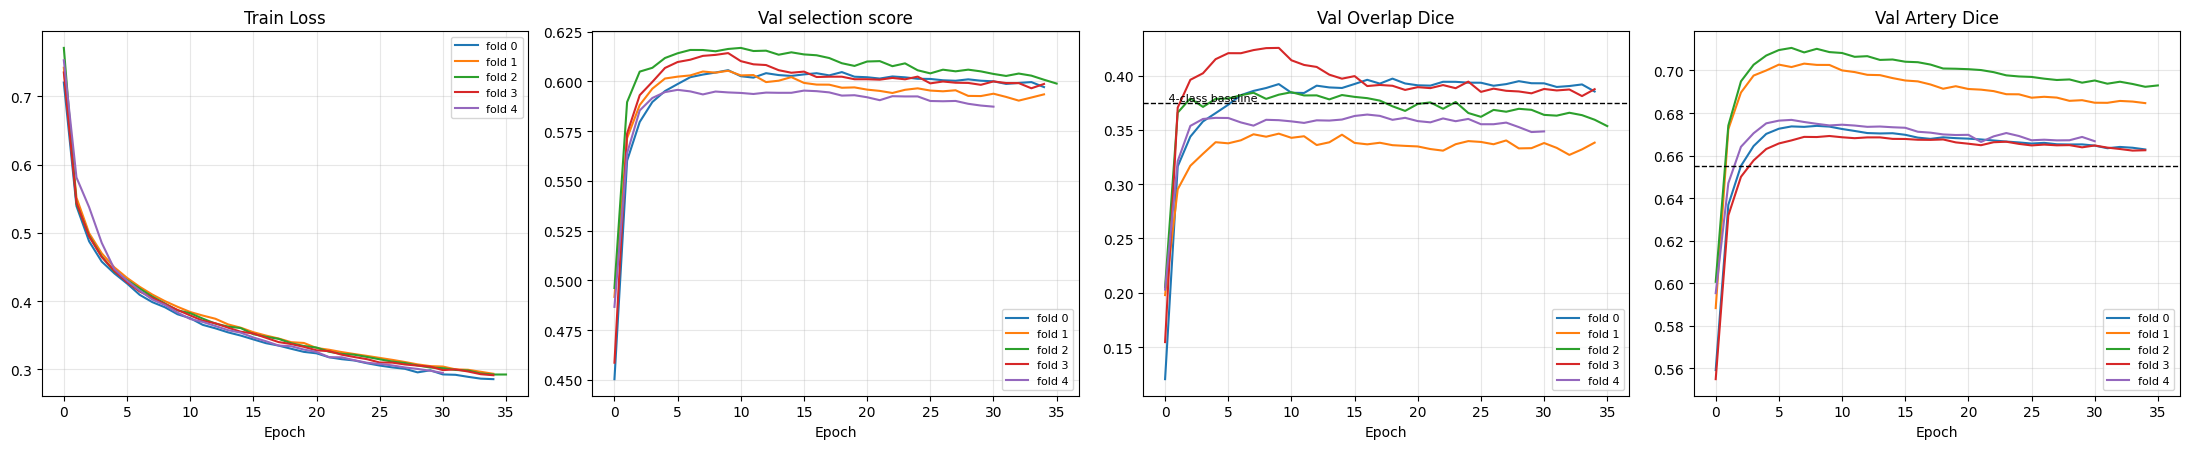

In [32]:
# =============================================================================
# Training Curves
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 4.6))

for f, h in enumerate(fold_histories):
    axes[0].plot(h["train_loss"], label=f"fold {f}")
    axes[1].plot(h["val_score"], label=f"fold {f}")
    axes[2].plot(h["val_overlap"], label=f"fold {f}")
    axes[3].plot(h["val_artery"], label=f"fold {f}")

for ax, title in zip(axes, ["Train Loss", "Val selection score",
                            "Val Overlap Dice", "Val Artery Dice"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[2].axhline(0.3748, ls="--", c="k", lw=1)
axes[2].text(0.02, 0.3748, " 4-class baseline", fontsize=8, va="bottom")

axes[3].axhline(0.6551, ls="--", c="k", lw=1)

plt.tight_layout()
plt.show()

In [33]:
# =============================================================================
# Held-Out Test Evaluation
# =============================================================================
#
# Run ONCE, after every configuration decision is frozen.
#
# Thresholds come from each fold's own validation sweep. They are never tuned
# on these frames -- doing so would turn the held-out set into a validation set.

test_results = []

for fold in range(N_FOLDS):

    ckpt = torch.load(fold_checkpoint(fold), map_location=DEVICE)

    model = build_model()

    _ref = model.state_dict()
    model.load_state_dict(
        {k: v.to(dtype=_ref[k].dtype) for k, v in ckpt["ema_state_dict"].items()}
    )

    res = evaluate_frames(model, TEST_STEMS,
                          thresholds=ckpt["thresholds"],
                          desc=f"test fold {fold}")

    test_results.append(res)

    print(f"fold {fold}: score {res['score']:.4f}  "
          f"overlap {res['overlap']['dice']:.4f}  tau {ckpt['thresholds']}")

summarise(test_results,
          f"HELD-OUT TEST ({len(TEST_STEMS)} frames, per-fold models)")

fold 0: score 0.5750  overlap 0.3351  tau [0.3, 0.4, 0.3]


fold 1: score 0.5810  overlap 0.3437  tau [0.3, 0.35, 0.3]


fold 2: score 0.5764  overlap 0.3346  tau [0.3, 0.6, 0.3]


fold 3: score 0.5713  overlap 0.3162  tau [0.3, 0.4, 0.3]


fold 4: score 0.5796  overlap 0.3348  tau [0.4, 0.7, 0.3]
HELD-OUT TEST (8 frames, per-fold models)
Selection   0.5767 +/- 0.0034   folds: [0.575, 0.581, 0.5764, 0.5713, 0.5796]
Accuracy    0.9787
------------------------------------------------------------------
class                 Dice             IoU     Prec      Rec
  artery    0.6607 +/-0.0027  0.4953 +/-0.0028    0.722    0.618
  vein      0.7364 +/-0.0022  0.5838 +/-0.0026    0.788    0.700
  vessel    0.7524 +/-0.0014  0.6035 +/-0.0017    0.769    0.739
  overlap   0.3329 +/-0.0090  0.2029 +/-0.0062    0.435    0.280
------------------------------------------------------------------
Significance: a change must exceed 2.0 x 0.0034 = 0.0069


{'score_mean': 0.5766581966231266, 'score_std': 0.003445904239957655}

fold 0 | epoch 9 | val score 0.6057 | tau [0.3, 0.4, 0.3]


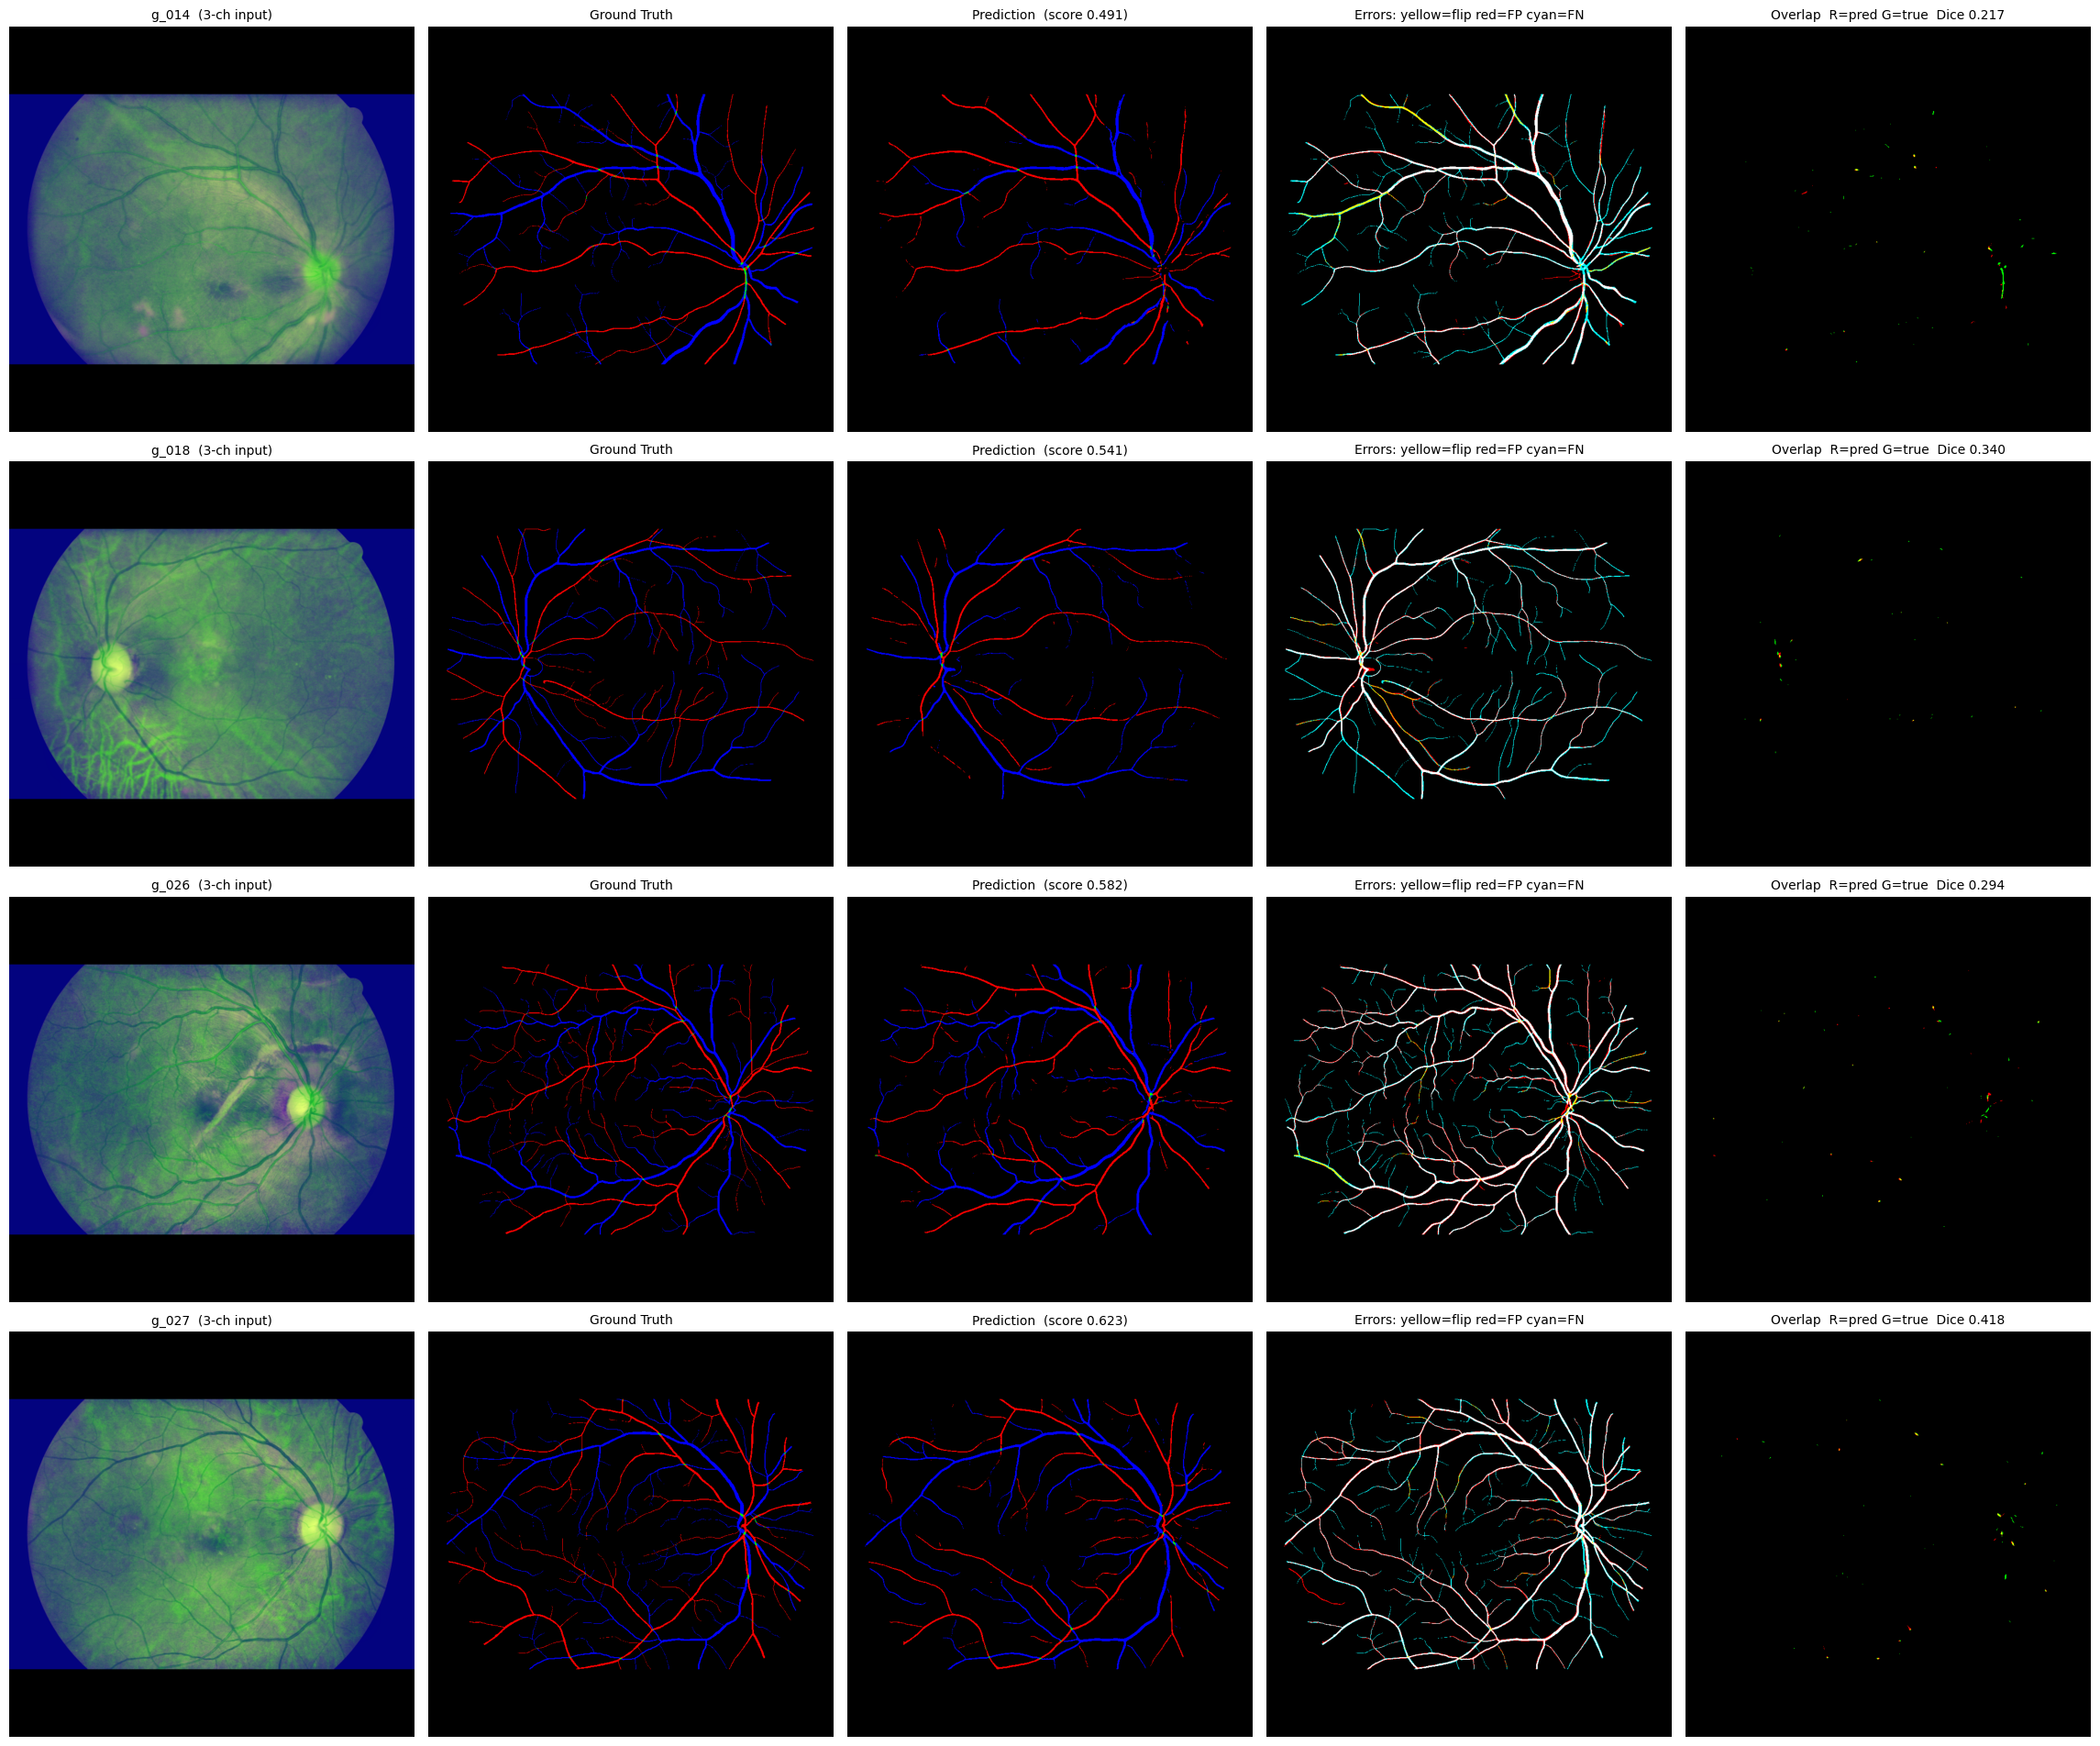

In [34]:
# =============================================================================
# Visualisation
# =============================================================================

VIS_FOLD = 0
VIS_N = 4


def load_fold_model(fold):

    ckpt = torch.load(fold_checkpoint(fold), map_location=DEVICE)

    model = build_model()

    _ref = model.state_dict()
    model.load_state_dict(
        {k: v.to(dtype=_ref[k].dtype) for k, v in ckpt["ema_state_dict"].items()}
    )

    model.eval()

    return model, ckpt


def channels_to_rgb(pa, pv):
    """artery red, vein blue, crossing green -- same palette as the GT."""

    h, w = pa.shape
    rgb = np.zeros((h, w, 3), np.uint8)

    rgb[pa & ~pv] = [255, 0, 0]
    rgb[pv & ~pa] = [0, 0, 255]
    rgb[pa & pv]  = [0, 255, 0]

    return rgb


model, ckpt = load_fold_model(VIS_FOLD)
tau = ckpt["thresholds"]

print(f"fold {VIS_FOLD} | epoch {ckpt['epoch']} | "
      f"val score {ckpt['val_score']:.4f} | tau {tau}")

stems = TEST_STEMS[:VIS_N]
ds = FrameDataset(stems)

fig, axes = plt.subplots(len(stems), 5, figsize=(23, 4.8 * len(stems)))

if len(stems) == 1:
    axes = axes[None, :]

for r, stem in enumerate(stems):

    image, target, overlap = ds[r]

    probs = torch.sigmoid(predict_frame(model, image))
    pb = binarise(probs.unsqueeze(0), tau)[0].cpu().numpy()

    pa, pv = pb[A_IDX], pb[V_IDX]

    ta = target[A_IDX].numpy() > 0.5
    tv = target[V_IDX].numpy() > 0.5
    tov = overlap.numpy() > 0.5

    m = multilabel_metrics(probs.unsqueeze(0),
                           target.unsqueeze(0).to(DEVICE),
                           overlap.unsqueeze(0).to(DEVICE), tau)

    err = np.zeros((*pa.shape, 3), np.uint8)
    pvz, tvz = pa | pv, ta | tv
    err[pvz & tvz] = [255, 255, 255]
    err[pvz & tvz & ((pa & ~ta) | (pv & ~tv))] = [255, 255, 0]
    err[pvz & ~tvz] = [255, 0, 0]
    err[~pvz & tvz] = [0, 255, 255]

    ov_pred = pa & pv

    panels = [
        (np.transpose(image.numpy(), (1, 2, 0)), f"{stem}  (3-ch input)"),
        (channels_to_rgb(ta, tv), "Ground Truth"),
        (channels_to_rgb(pa, pv),
         f"Prediction  (score {m['score'] if 'score' in m else selection_score(m):.3f})"),
        (err, "Errors: yellow=flip red=FP cyan=FN"),
        (np.stack([ov_pred, tov, np.zeros_like(tov)], -1).astype(np.uint8) * 255,
         f"Overlap  R=pred G=true  Dice {m['overlap']['dice']:.3f}"),
    ]

    for c, (im, title) in enumerate(panels):
        axes[r, c].imshow(im)
        axes[r, c].set_title(title, fontsize=10)
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

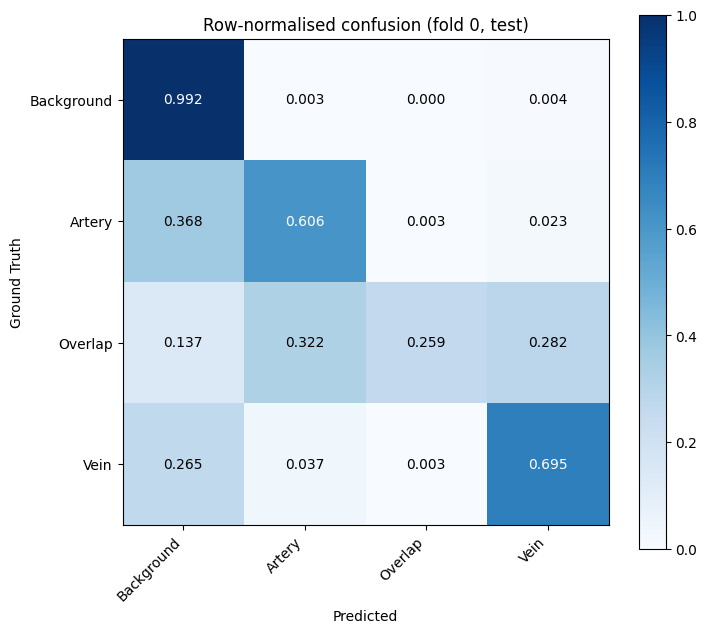


Row 'Overlap' shows where crossings actually go.
Mass leaking into Artery/Vein = the model committed to one identity
instead of firing both channels.


In [35]:
# =============================================================================
# Confusion Matrix -- reconstructed 4-class map
# =============================================================================

from sklearn.metrics import confusion_matrix

model, ckpt = load_fold_model(VIS_FOLD)
tau = ckpt["thresholds"]

ds = FrameDataset(TEST_STEMS)

all_pred, all_true = [], []

for i in range(len(ds)):

    image, target, overlap = ds[i]

    probs = torch.sigmoid(predict_frame(model, image)).unsqueeze(0)

    m = multilabel_metrics(probs, target.unsqueeze(0).to(DEVICE),
                           overlap.unsqueeze(0).to(DEVICE), tau)

    all_pred.append(m["_pred_cls"].cpu().numpy().ravel())
    all_true.append(m["_true_cls"].cpu().numpy().ravel())

cm = confusion_matrix(np.concatenate(all_true), np.concatenate(all_pred),
                      labels=[0, 1, 2, 3])

cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

names = ["Background", "Artery", "Overlap", "Vein"]

fig, ax = plt.subplots(figsize=(7.5, 6.5))

im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(4)); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(4)); ax.set_yticklabels(names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
ax.set_title(f"Row-normalised confusion (fold {VIS_FOLD}, test)")

for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm_norm[i, j]:.3f}", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=10)

fig.colorbar(im)
plt.tight_layout()
plt.show()

print("\nRow 'Overlap' shows where crossings actually go.")
print("Mass leaking into Artery/Vein = the model committed to one identity")
print("instead of firing both channels.")